In [68]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [69]:
import numpy as np
import torch

from main.arquitetura.CLDNN.model import *
from main.arquitetura.CLDNN.train import train_epoch, generate


model = CLDNNEncoder(n_mels=80,
                     conv_channels=(32, 64),
                     gru_hidden=256,
                     gru_layers=3,
                     proj_dim=256,
                     bidirectional=True,
                     causal=False,
                     conv_pool=[False, False]).to("cuda")  # change pooling if desired
vel = CondUNet(in_ch=1, base_ch=48, time_emb_dim=128, cond_dim=256).to('cuda')
optim = torch.optim.Adam(list(model.parameters()) + list(vel.parameters()), lr=2e-5)


In [70]:

from main.data_loader.CVMPT.CVMPT_offline import CVMPT_offline
import torch

def collate(batch):
    B = len(batch)

    audio_v = [item["audio"] for item in batch]
    sr_v = [item["sample_rate"] for item in batch]
    sentence_v = [item["sentence"] for item in batch]

    # mel e mel_noise: (T, 80) após permute
    mel_list = [item["mel"].permute(1, 0) for item in batch]
    meln_list = [item["mel_noise"].permute(1, 0) for item in batch]

    # Se mel_v realmente é "stackável", ele precisa ter mesmo T em todos
    # (se não tiver, tem que pad também)
    mel_v = torch.stack(mel_list, dim=0)  # (B, T, 80)

    # Padding eficiente do mel_noise
    lengths = [x.shape[0] for x in meln_list]
    T_max = max(lengths)
    C = meln_list[0].shape[1]

    # Cria no mesmo device/dtype do mel_noise (evita CPU->GPU extra)
    ref = meln_list[0]
    mel_noise_v = torch.zeros((B, T_max, C), dtype=ref.dtype, device=ref.device)

    for i, x in enumerate(meln_list):
        t = x.shape[0]
        mel_noise_v[i, :t] = x

    return audio_v, mel_v, mel_noise_v, sr_v, sentence_v

train_set = CVMPT_offline(path=r"C:\Users\USER\Documents\Mestrado\codigo\Mestrado_VC\dataset\cv-corpus-mozilla-pt\data\Treinamento")
valid_set = CVMPT_offline(path=r"C:\Users\USER\Documents\Mestrado\codigo\Mestrado_VC\dataset\cv-corpus-mozilla-pt\data\Teste")

train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size=4,
    shuffle=True,
    collate_fn=collate
)

valid_loader = torch.utils.data.DataLoader(
    valid_set,
    batch_size=1,
    shuffle=False,
    collate_fn=collate
)


Epoch: 0


Treinamento:   0%|          | 0/5576 [00:00<?, ?it/s]

Validacao:   0%|          | 0/9579 [00:00<?, ?it/s]

HiFi-GAN: Removing weight norm.
epoch 0 avg loss 1.677943
Epoch: 1


Treinamento:   0%|          | 0/5576 [00:00<?, ?it/s]

...

Treinamento:   0%|          | 0/5576 [00:00<?, ?it/s]

Validacao:   0%|          | 0/9579 [00:00<?, ?it/s]

HiFi-GAN: Removing weight norm.
epoch 49 avg loss 0.552827


MDC,█▆▄▃▅▃▂▃▃▃▃▂▂▂▂▃▃▂▂▂▂▃▂▁▂▂▂▁▂▁▁▂▃▂▂▁▂▂▂▁
PSNR,▁▂▄▅▅▆▆▆▆▆▅▇▇▇▇▇▇▇▇▇▇▇▇▇█▇████████▇█████
SNR,▁▃▄▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇██████████▇██████
WER,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epocas,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
loss_train,█▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
loss_val,██▅▄▃▄▃▂▃▂▄▂▂▂▂▃▂▂▂▂▂▂▂▂▂▁▂▁▂▁▁▁▂▂▁▁▁▁▁▁
MDC,92.7234
PSNR,51.02107
SNR,12.80923
WER,-1


TypeError: Invalid shape (740,) for image data

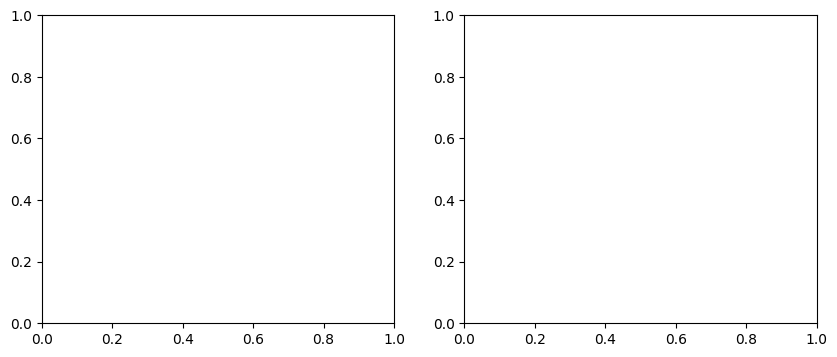

In [71]:
from main.vocoder.HiFiGAN import sr_hifigan
from main.arquitetura.CLDNN.validation import validation
from main.pre_processamento.spectograma import mel_to_rgb
import wandb

project="Laringe Eletronica - Mestrado VC"

config = {
    "epocas": 50
}

with wandb.init(project=project,config=config) as run:
    
    for ep in range(config["epocas"]):
        print(f"Epoch: {ep}")
        loss = train_epoch(train_loader,model , vel, device='cuda',optim=optim,log_every=1000)
        relatorio = validation(model,vel,valid_loader,device='cuda',on_wer=False)
        
        run.log({
            "MDC": relatorio.mdc,
            "WER": relatorio.wer,
            "SNR": relatorio.snr,
            "PSNR": relatorio.psnr,
            "loss_train": loss,
            "loss_val": relatorio.loss,
            "mel_exemple":{
                "ground_truth": wandb.Image(mel_to_rgb(relatorio.grouth_truth)),
                "prediction": wandb.Image(mel_to_rgb(relatorio.pred))
            },
            "audio_exemple":{
                "ground_truth": wandb.Audio(relatorio.audio,sample_rate=relatorio.sr),
                "noise":wandb.Audio(relatorio.audio_noise,sample_rate=relatorio.sr),
                "prediction": wandb.Audio(relatorio.audio_pred,sample_rate= sr_hifigan()),
            },
            "epocas": ep+1
        })
        print(f"epoch {ep} avg loss {loss:.6f}")
        
relatorio.gerar_relatorio_visual()